In [1]:
import numpy as np
import pandas as pd

In [2]:
import seaborn as sns 

In [3]:
data = {
    "A": [1,2,100,4,5],
    "B": [3, np.nan, 7,8,9],
    "C": [np.nan, 12,13,14,15], 
    "D": [16,17,18,np.nan,20]
}

df = pd.DataFrame(data)
print("Original DataFrame:")
print(df)

Original DataFrame:
     A    B     C     D
0    1  3.0   NaN  16.0
1    2  NaN  12.0  17.0
2  100  7.0  13.0  18.0
3    4  8.0  14.0   NaN
4    5  9.0  15.0  20.0


In [4]:
#df.isnull().sum() -> count of null values in each column
print("\nCount of null values in each column:")
print(df.isnull().sum())


Count of null values in each column:
A    0
B    1
C    1
D    1
dtype: int64


In [5]:
# droping rows with null values 
df_dropped = df.dropna()
print("\nDataFrame after dropping rows with null values:")
print(df_dropped)


DataFrame after dropping rows with null values:
     A    B     C     D
2  100  7.0  13.0  18.0
4    5  9.0  15.0  20.0


In [6]:
# droping columns with null values
df_dropped_cols = df.dropna(axis=1)
print("\nDataFrame after dropping columns with null values:")
print(df_dropped_cols)


DataFrame after dropping columns with null values:
     A
0    1
1    2
2  100
3    4
4    5


Imputation 

In [7]:
df

,A,B,C,D
0,1,3.0,NaN,16.0
1,2,NaN,12.0,17.0
2,100,7.0,13.0,18.0
3,4,8.0,14.0,NaN
4,5,9.0,15.0,20.0


In [10]:
#fill the b with mean value 
print(f"mean of coulmn B is {df['B'].mean()}")
df['B'].fillna(df['B'].mean())# we are not doing inplace = True. So oringinal df will not change.

mean of coulmn B is 6.75


0    3.00
1    6.75
2    7.00
3    8.00
4    9.00
Name: B, dtype: float64

In [11]:
# replacing missing values with median
print(f"median of coulmn B is {df['B'].median()}") 
df['B'].fillna(df['B'].median())

median of coulmn B is 7.5


0    3.0
1    7.5
2    7.0
3    8.0
4    9.0
Name: B, dtype: float64

In [12]:
df_titanic = sns.load_dataset('titanic')
df_titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
# lets see the null values 
print(df_titanic.isnull().sum())
print(df_titanic.shape)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
(891, 15)


In [17]:
# dropna() -> drops rows with null values
df_titanic_dropped = df_titanic.dropna()
print("\nDataFrame after dropping rows with null values:")
print(df_titanic_dropped.head())
print(df_titanic_dropped.shape)


DataFrame after dropping rows with null values:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1          1       1  female  38.0      1      0  71.2833        C  First   
3          1       1  female  35.0      1      0  53.1000        S  First   
6          0       1    male  54.0      0      0  51.8625        S  First   
10         1       3  female   4.0      1      1  16.7000        S  Third   
11         1       1  female  58.0      0      0  26.5500        S  First   

      who  adult_male deck  embark_town alive  alone  
1   woman       False    C    Cherbourg   yes  False  
3   woman       False    C  Southampton   yes  False  
6     man        True    E  Southampton    no   True  
10  child       False    G  Southampton   yes  False  
11  woman       False    C  Southampton   yes   True  
(182, 15)


In [18]:
# lets drop columns with null values
print(f"oringinal shape :{df_titanic.shape}")
df_titanic_drop_cols = df_titanic.dropna(axis=1)
print("\nDataFrame after dropping columns with null values:")
print(df_titanic_drop_cols.head())
print(f"after dropping columns shape : {df_titanic_drop_cols.shape}")

oringinal shape :(891, 15)

DataFrame after dropping columns with null values:
   survived  pclass     sex  sibsp  parch     fare  class    who  adult_male  \
0         0       3    male      1      0   7.2500  Third    man        True   
1         1       1  female      1      0  71.2833  First  woman       False   
2         1       3  female      0      0   7.9250  Third  woman       False   
3         1       1  female      1      0  53.1000  First  woman       False   
4         0       3    male      0      0   8.0500  Third    man        True   

  alive  alone  
0    no  False  
1   yes  False  
2   yes   True  
3   yes  False  
4    no   True  
after dropping columns shape : (891, 11)


In [19]:
df_titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: xlabel='age', ylabel='Count'>

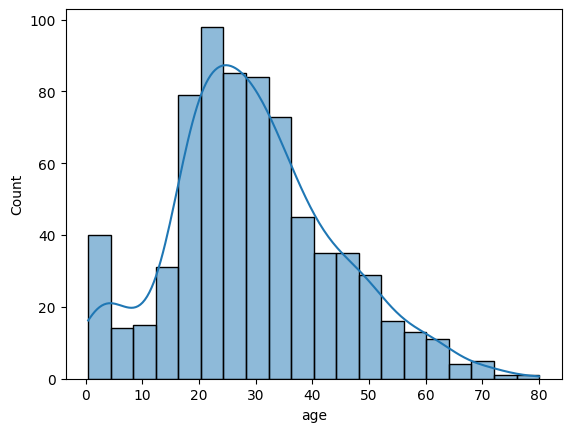

In [21]:
# lets foucs on age column 
sns.histplot(df_titanic['age'], kde=True)

In [22]:
# the plot is almost normal distribution but there are some missing values.
# We can fill those missing values with mean or median.
# But since there are some outliers in age column, we will use median to fill those missing values.
# Or if we treat the outliers first and then use mean to fill the missing values. 


In [27]:
df = sns.load_dataset('titanic')
df['age_imputed'] = df['age'].fillna(df['age'].median())
df[['age', 'age_imputed']].head(10)

,age,age_imputed
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
5,NaN,28.0
6,54.0,54.0
7,2.0,2.0
8,27.0,27.0
9,14.0,14.0


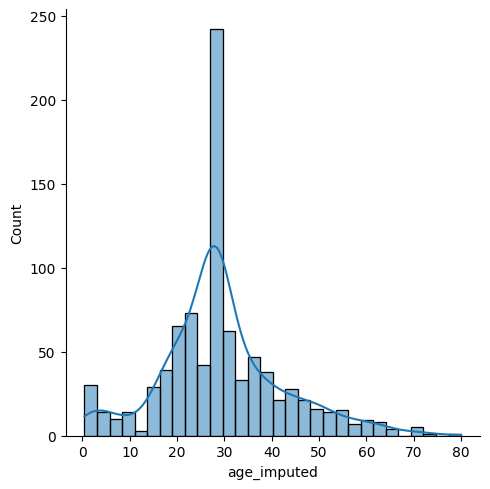

In [28]:
sns.displot(df['age_imputed'], kde=True)

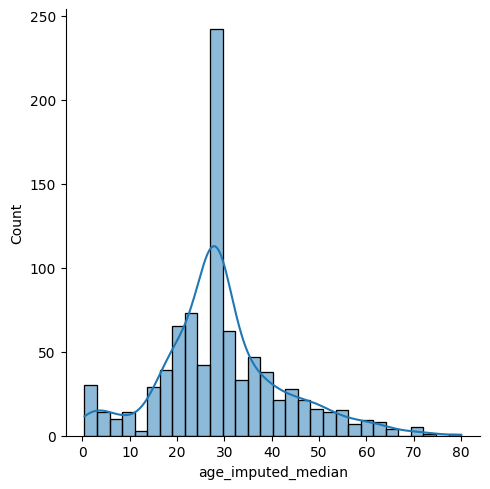

In [29]:
#lets do median imputation 
df['age_imputed_median'] = df['age'].fillna(df['age'].median())
sns.displot(df['age_imputed_median'], kde=True)

In [30]:
# imputation of categorical data with mode

In [31]:
df['embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

In [32]:
# let's see the unique values 
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [33]:
#lets see the null values column 
df[df['embarked'].isnull()] #-> shows rows with null values in embarked column

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_imputed,age_imputed_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [38]:
# lets see the coulmn where no null values ae present 
df[df['embarked'].notna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_imputed,age_imputed_median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,27.0,27.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,19.0,19.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,28.0,28.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,26.0,26.0


In [ ]:
modeValue = df[df['embarked'].notna()]['embarked'].mode()[0]  # mode returns a series. So we take the first value. 0 means first mode 

In [53]:
df['embarked'].fillna(modeValue)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

In [49]:
df['embarked'].notna()

0      True
1      True
2      True
3      True
4      True
       ... 
886    True
887    True
888    True
889    True
890    True
Name: embarked, Length: 891, dtype: bool

In [54]:
# instead of finding mode value form non null values, we can directly find mode from the entire column as mode ignores null values by default.
modeValue = df['embarked'].mode()[0]
print(modeValue)

S
